In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import xgboost
from xgboost import XGBClassifier
from xgboost import to_graphviz

In [ ]:
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred)*100, 2)
    recall = round(recall_score(y_actual, y_pred)*100, 2)
    f1 = round(f1_score(y_actual, y_pred)*100, 2)
    return {"Accuracy":acc, "Precision":precision, "Recall":recall, "F1":f1}

In [ ]:
# Loading dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    'age','workclass','fnlwgt','education','education_num','marital_status',
    'occupation','relationship','race','sex','capital_gain','capital_loss',
    'hours_per_week','native_country','income'
]

In [ ]:
df = pd.read_csv(url, header=None, names=columns, na_values=" ?")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.income.value_counts()

,count
income,
<=50K,24720
>50K,7841


In [ ]:
df.shape

(32561, 15)

In [ ]:
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df = df.dropna()
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.shape

(30162, 15)

In [ ]:
# encoding categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("income", axis=1)
y = df["income"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# decision tree
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
classification_metrics(y_test, y_pred_dt)

{'Accuracy': 83.67, 'Precision': 78.38, 'Recall': 47.54, 'F1': 59.18}

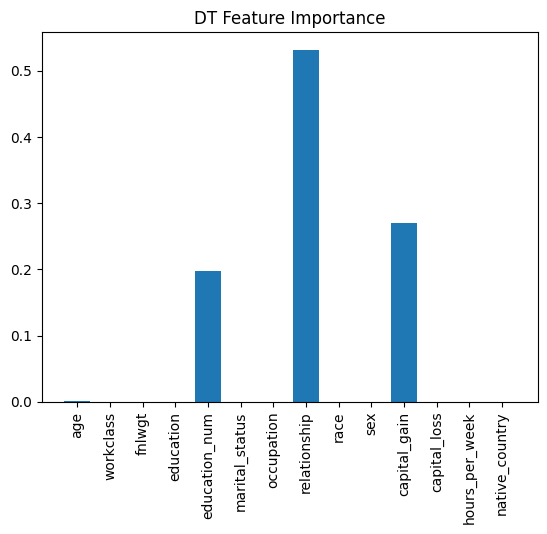

In [ ]:
plt.figure()
plt.bar(X.columns, dt.feature_importances_)
plt.xticks(rotation=90)
plt.title("DT Feature Importance")
plt.show()

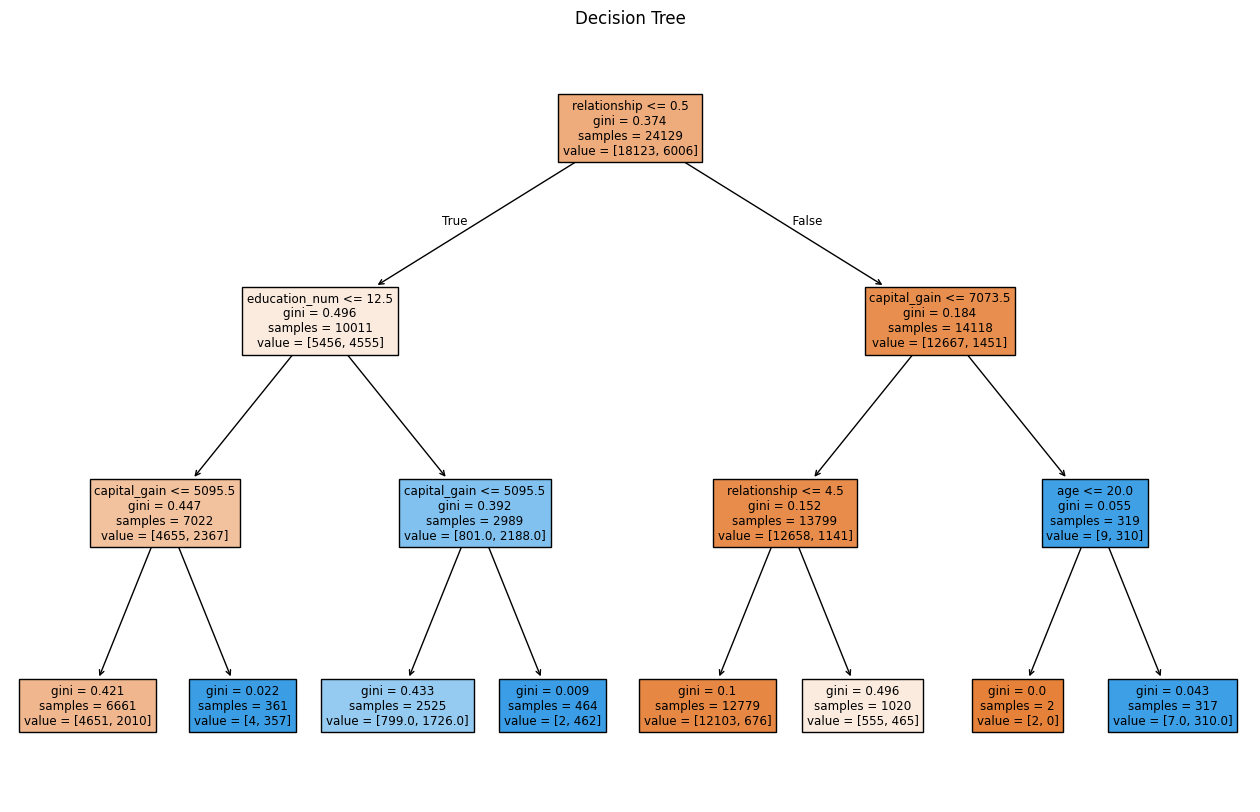

In [ ]:
plt.figure(figsize=(16,10))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.title("Decision Tree")
plt.show()

In [ ]:
# random forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
classification_metrics(y_test, y_pred_rf)

{'Accuracy': 85.26, 'Precision': 79.5, 'Recall': 54.99, 'F1': 65.01}

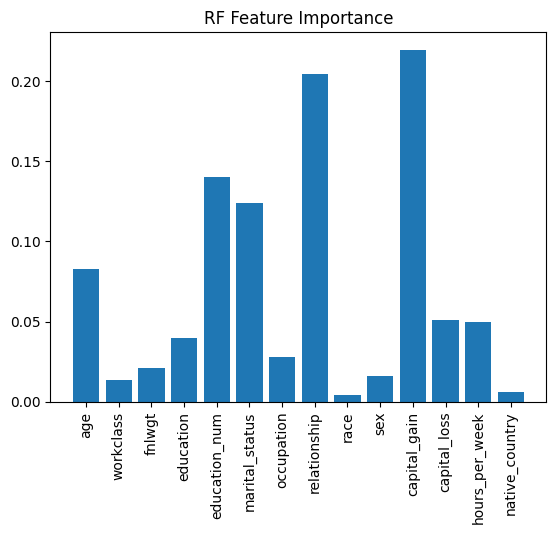

In [ ]:
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title("RF Feature Importance")
plt.show()

In [ ]:
# gradient boosting
gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
classification_metrics(y_test, y_pred_gb)

{'Accuracy': 85.89, 'Precision': 78.38, 'Recall': 59.85, 'F1': 67.87}

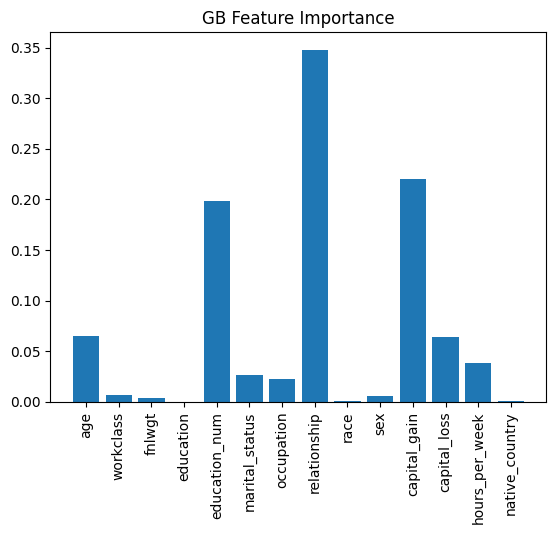

In [ ]:
plt.figure()
plt.bar(X.columns, gb.feature_importances_)
plt.xticks(rotation=90)
plt.title("GB Feature Importance")
plt.show()

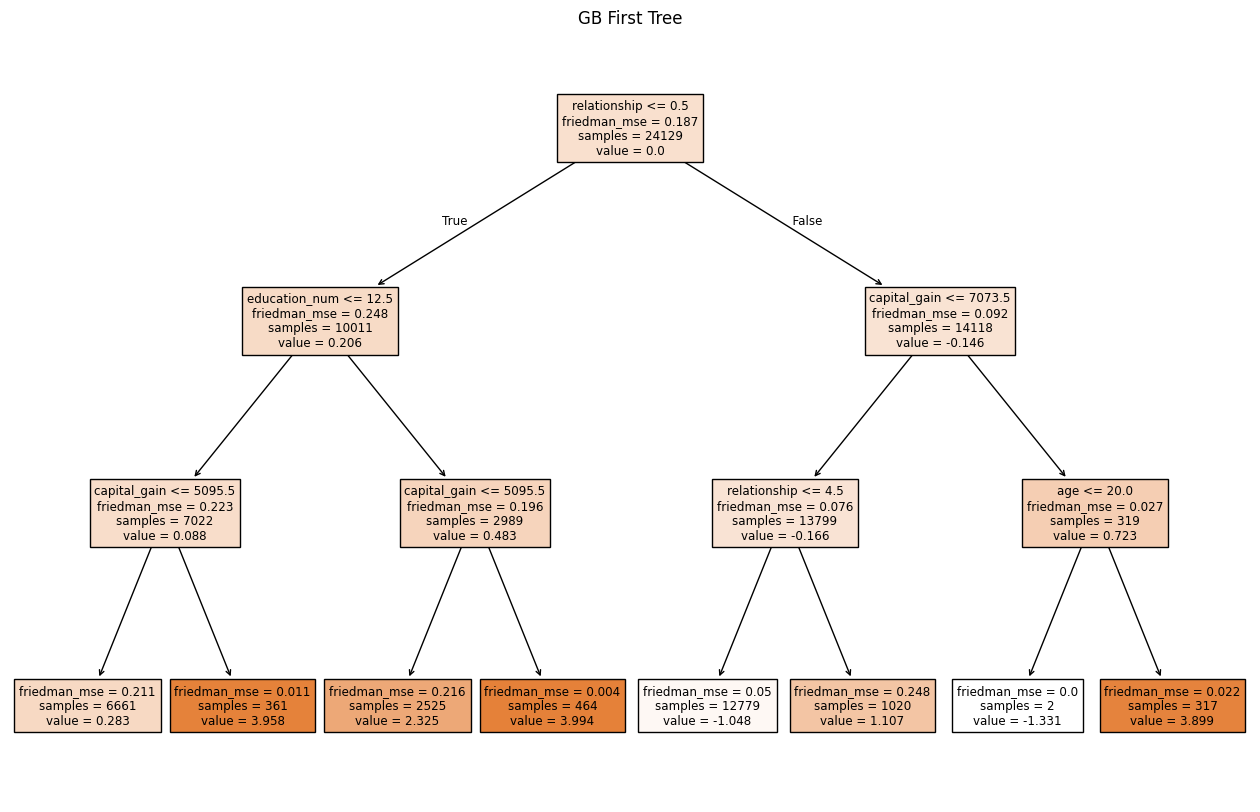

In [ ]:
# visualize one tree
plt.figure(figsize=(16,10))
plot_tree(gb.estimators_[0,0], feature_names=X.columns, filled=True)
plt.title("GB First Tree")
plt.show()

In [ ]:
# XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
classification_metrics(y_test, y_pred_xgb)

{'Accuracy': 86.44, 'Precision': 77.94, 'Recall': 63.52, 'F1': 69.99}

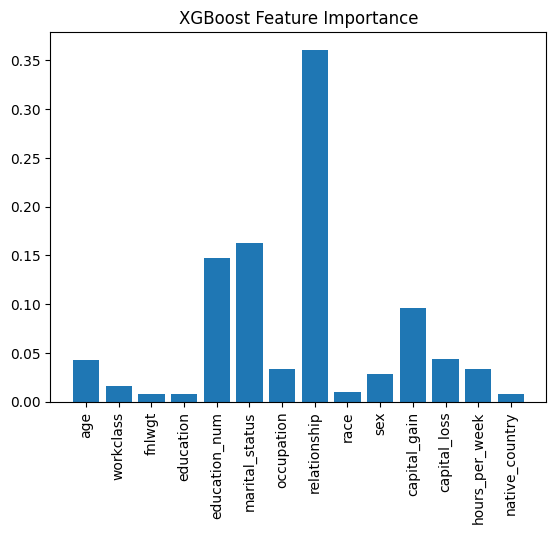

In [ ]:
# Feature importance
plt.figure()
plt.bar(X.columns, xgb.feature_importances_)
plt.xticks(rotation=90)
plt.title("XGBoost Feature Importance")
plt.show()

<Figure size 4000x3000 with 0 Axes>

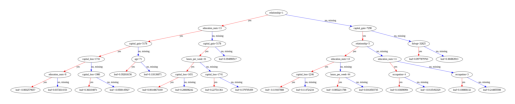

In [ ]:
plt.figure(figsize=(40, 30))
xgboost.plot_tree(xgb, tree_idx=0) # plots the first tree at index 0
plt.show()

In [ ]:
# saving to a file
dot = to_graphviz(xgb, tree_idx=0)
dot.render("xgboost_tree")

'xgboost_tree.pdf'

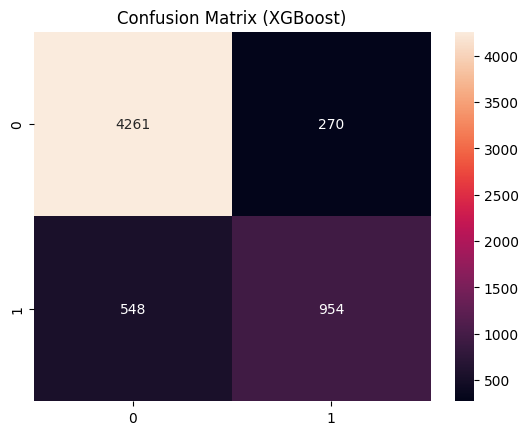

In [ ]:
# best-performing model
best_pred = y_pred_xgb
cm = confusion_matrix(y_test, best_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

**Exercise**
1. Use cross-validation on the above problem. How does this affect performance if at all?
2. Select two models and perform hyperparameter optimization to select the best hyperparameters. How does this affect the performance of the models?
3. Choose a simple regression problem of your choice and use the above algorithms for prediction. Provide a comparison of their performance and their feature importance.

In [39]:
#Use cross-validation on the above problem. How does this affect performance if at all?
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=40)

scores = cross_val_score(dt, X, y, cv=kf)
print(f"decison tree: {scores}")
print(f"Decision Tree: {scores.mean():.2f}")


scores = cross_val_score(rf, X, y, cv=kf)
print(f"Random Forest: {scores.mean():.2f}")

scores = cross_val_score(gb, X, y, cv=kf)
print(f"Gradient Boosting: {scores.mean():.2f}")

scores = cross_val_score(xgb, X, y, cv=kf)
print(f"XGBoost: {scores.mean():.2f}")
#cross validation gives the most accurate result of the modal which makes it possible to adjust incase its irrelevant

decison tree: [0.83988066 0.8297696  0.8362069  0.84084881 0.83272546]
Decision Tree: 0.84
Random Forest: 0.85
Gradient Boosting: 0.86
XGBoost: 0.87


In [ ]:
#Select two models and perform hyperparameter optimization to select the best hyperparameters. How does this affect the performance of the models?


## Hyperparameter Optimization

I will select two models, `RandomForestClassifier` and `XGBClassifier`, for hyperparameter optimization. We will use `GridSearchCV` to find the best hyperparameters for these models. After finding the optimal parameters, I will train the models with these new settings and compare their performance with the previously trained models.

In [40]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV for RandomForestClassifier
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                            param_grid=param_grid_rf,
                            cv=3,
                            scoring='f1',
                            n_jobs=-1,
                            verbose=1)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Best Parameters for Random Forest: {best_params_rf}")
print(f"Best F1-score for Random Forest: {best_score_rf:.2f}")

# Train Random Forest with best parameters
optimized_rf = RandomForestClassifier(**best_params_rf, random_state=42)
optimized_rf.fit(X_train, y_train)
y_pred_optimized_rf = optimized_rf.predict(X_test)

print("\nPerformance of Optimized Random Forest:")
display(classification_metrics(y_test, y_pred_optimized_rf))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters for Random Forest: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-score for Random Forest: 0.69

Performance of Optimized Random Forest:


{'Accuracy': 85.93, 'Precision': 77.98, 'Recall': 60.59, 'F1': 68.19}

Next, let's perform hyperparameter optimization for the `XGBClassifier`.

In [41]:
# Define the parameter grid for XGBClassifier
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'gamma': [0, 0.1, 0.2] # Minimum loss reduction required to make a further partition
}

# Initialize GridSearchCV for XGBClassifier
grid_search_xgb = GridSearchCV(estimator=XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
                            param_grid=param_grid_xgb,
                            cv=3,
                            scoring='f1',
                            n_jobs=-1,
                            verbose=1)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Best Parameters for XGBoost: {best_params_xgb}")
print(f"Best F1-score for XGBoost: {best_score_xgb:.2f}")

# Train XGBoost with best parameters
optimized_xgb = XGBClassifier(**best_params_xgb, eval_metric='logloss', use_label_encoder=False, random_state=42)
optimized_xgb.fit(X_train, y_train)
y_pred_optimized_xgb = optimized_xgb.predict(X_test)

print("\nPerformance of Optimized XGBoost:")
display(classification_metrics(y_test, y_pred_optimized_xgb))

Fitting 3 folds for each of 81 candidates, totalling 243 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:29:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'gamma': 0.1, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best F1-score for XGBoost: 0.72


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:29:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Performance of Optimized XGBoost:


{'Accuracy': 86.52, 'Precision': 77.45, 'Recall': 64.71, 'F1': 70.51}

## Comparison of Model Performances

Let's compare the performance metrics of the models before and after hyperparameter optimization.

**Original Model Performances (from previous cells):**
*   **Decision Tree:** `{'Accuracy': 83.67, 'Precision': 78.38, 'Recall': 47.54, 'F1': 59.18}`
*   **Random Forest:** `{'Accuracy': 85.26, 'Precision': 79.5, 'Recall': 54.99, 'F1': 65.01}`
*   **Gradient Boosting:** `{'Accuracy': 85.89, 'Precision': 78.38, 'Recall': 59.85, 'F1': 67.87}`
*   **XGBoost:** `{'Accuracy': 86.44, 'Precision': 77.94, 'Recall': 63.52, 'F1': 69.99}`

**Optimized Model Performances:**

(The results for the optimized models will be displayed above after the code execution. We can then compare them here.)

Hyperparameter optimization generally leads to improved model performance by finding the combination of parameters that minimizes error or maximizes a chosen metric on unseen data. It helps in making the model more robust and less prone to overfitting or underfitting, ultimately leading to better generalization.

## Exercise 3: Regression Problem

For the regression problem, I'll use the California Housing dataset, which is a classic dataset for regression tasks. The goal will be to predict the median house value in California districts given various features.

In [42]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
X_reg = housing.data
y_reg = housing.target

print("California Housing Dataset loaded.")
print(f"Features shape: {X_reg.shape}")
print(f"Target shape: {y_reg.shape}")

# Split the dataset into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train_reg.shape}")
print(f"Testing data shape: {X_test_reg.shape}")

# Define a function to evaluate regression models
def regression_metrics(y_actual, y_pred):
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)
    return {"MSE": round(mse, 2), "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 2)}


California Housing Dataset loaded.
Features shape: (20640, 8)
Target shape: (20640,)
Training data shape: (16512, 8)
Testing data shape: (4128, 8)


In [43]:
# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt_reg = dt_reg.predict(X_test_reg)

print("Decision Tree Regressor Performance:")
display(regression_metrics(y_test_reg, y_pred_dt_reg))

Decision Tree Regressor Performance:


{'MSE': 0.5, 'RMSE': np.float64(0.7), 'MAE': 0.45, 'R2': 0.62}

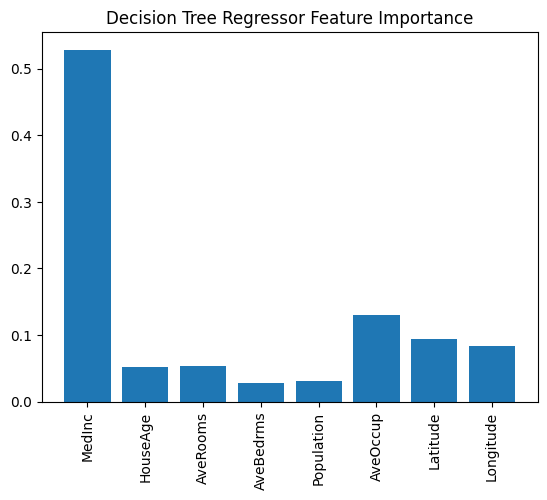

In [44]:
plt.figure()
plt.bar(X_reg.columns, dt_reg.feature_importances_)
plt.xticks(rotation=90)
plt.title("Decision Tree Regressor Feature Importance")
plt.show()

In [45]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

print("Random Forest Regressor Performance:")
display(regression_metrics(y_test_reg, y_pred_rf_reg))

Random Forest Regressor Performance:


{'MSE': 0.26, 'RMSE': np.float64(0.51), 'MAE': 0.33, 'R2': 0.81}

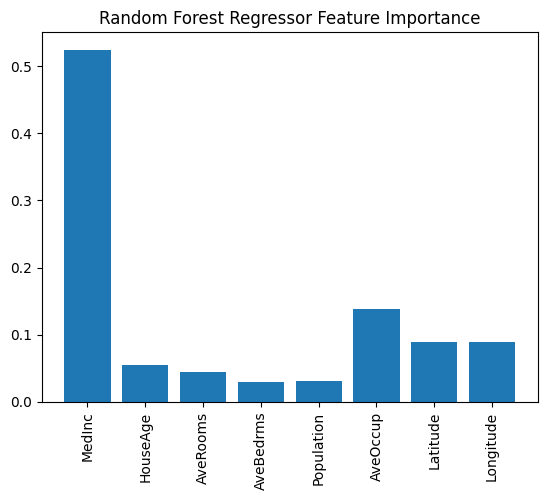

In [46]:
plt.figure()
plt.bar(X_reg.columns, rf_reg.feature_importances_)
plt.xticks(rotation=90)
plt.title("Random Forest Regressor Feature Importance")
plt.show()

In [47]:
# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)
y_pred_gb_reg = gb_reg.predict(X_test_reg)

print("Gradient Boosting Regressor Performance:")
display(regression_metrics(y_test_reg, y_pred_gb_reg))

Gradient Boosting Regressor Performance:


{'MSE': 0.29, 'RMSE': np.float64(0.54), 'MAE': 0.37, 'R2': 0.78}

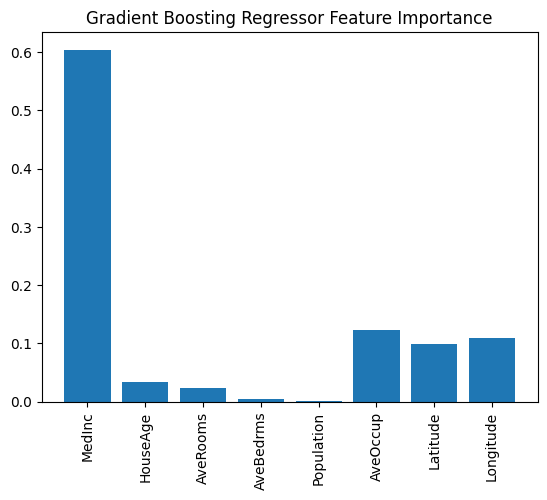

In [48]:
plt.figure()
plt.bar(X_reg.columns, gb_reg.feature_importances_)
plt.xticks(rotation=90)
plt.title("Gradient Boosting Regressor Feature Importance")
plt.show()

In [49]:
# XGBoost Regressor
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train_reg, y_train_reg)
y_pred_xgb_reg = xgb_reg.predict(X_test_reg)

print("XGBoost Regressor Performance:")
display(regression_metrics(y_test_reg, y_pred_xgb_reg))

XGBoost Regressor Performance:


{'MSE': 0.22, 'RMSE': np.float64(0.47), 'MAE': 0.31, 'R2': 0.83}

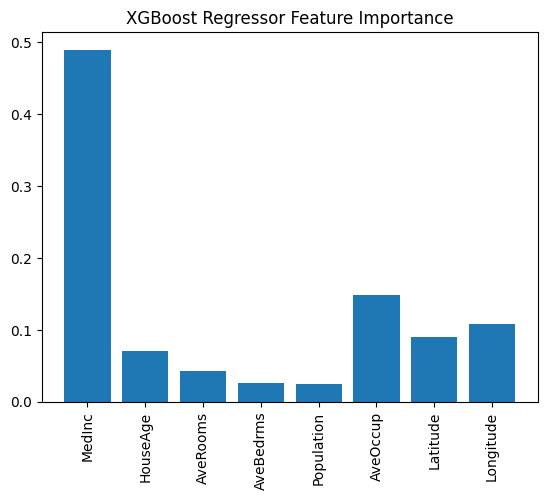

In [50]:
plt.figure()
plt.bar(X_reg.columns, xgb_reg.feature_importances_)
plt.xticks(rotation=90)
plt.title("XGBoost Regressor Feature Importance")
plt.show()